# Análise descritiva dos datasets

Panorama dos conjuntos de dados utilizados: volume, distribuição de rótulos e atributos sensíveis.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path[:0] = [str(ROOT)]

from auxiliar_analysis.analysis_utils import set_plot_style
from auxiliar_analysis.dataset_analysis_utils import (
    load_combined_data,
    build_target_distribution_table,
    build_sensitive_group_table,
    plot_target_by_sensitive_group,
    plot_feature_distributions,
    build_dataset_overview_table,
)
from auxiliar_analysis.config import DATASET_CONFIGS, ANALYSIS_PATH

set_plot_style(
    palette=["#4E79A7", "#76B7B2", "#F28E2B"],
    background="whitegrid",
    font="Arial",
    font_scale=1.1,
)

In [2]:
# Diretórios de saída
OUT_BASE = ANALYSIS_PATH / "dataset_overview"
FIGS = OUT_BASE / "figs"
TABLES = OUT_BASE / "tables"
for p in (FIGS, TABLES):
    p.mkdir(parents=True, exist_ok=True)

data_root = ROOT / "data" / "processed"

## Carregamento dos dados

In [3]:
combined = load_combined_data(data_root=data_root)
print(f"Total de amostras: {len(combined):,}")
print(f"Datasets: {combined['dataset'].nunique()}")
combined.head()

Total de amostras: 6,760
Datasets: 6


,sensitive_group,target,dataset,_dataset_key
0,1,0,Heart Disease,HEART
1,1,1,Heart Disease,HEART
2,1,1,Heart Disease,HEART
3,1,0,Heart Disease,HEART
4,0,0,Heart Disease,HEART


## Tabelas descritivas

In [4]:
# Tabela unificada: descrição dos datasets (volume + propriedades + referências)
overview_table = build_dataset_overview_table(combined, result_dir=TABLES)


Tabela salva em: experiments\results\analysis\dataset_overview\tables\table_dataset_overview.tex
| Conjunto de dados                                       | Rótulo favorável     |   Taxa fav. (\%) |   $N$ | Atributo protegido   | Privilegiado   | Desprivilegiado   |
|:--------------------------------------------------------|:---------------------|-----------------:|------:|:---------------------|:---------------|:------------------|
| \textbf{Heart Disease} \newline \cite{heart_disease_45} | Sem doença cardíaca  |               54 |   297 | Sex                  | Masculino      | Feminino          |
| \textbf{Aids} \newline \cite{aids_dataset}              | Sem óbito            |               76 |  2139 | Homo                 | Heterossexual  | Homossexual       |
| \textbf{Obesity} \newline \cite{palechor2019obesity}    | Sem obesidade severa |               71 |  2111 | Gender               | Masculino      | Feminino          |
| \textbf{Arrhythmia} \newline \cite{arrhythmia_5}   

In [5]:
# Distribuição de target (rótulo) por dataset
target_table = build_target_distribution_table(combined, result_dir=TABLES)

Tabela salva em: experiments\results\analysis\dataset_overview\tables\table_dist_target.tex
| dataset       |   target |    n |    share |
|:--------------|---------:|-----:|---------:|
| Aids          |        0 | 1618 | 0.756428 |
| Aids          |        1 |  521 | 0.243572 |
| Arrhythmia    |        0 |  245 | 0.542035 |
| Arrhythmia    |        1 |  207 | 0.457965 |
| Diabetes      |        0 |  200 | 0.384615 |
| Diabetes      |        1 |  320 | 0.615385 |
| Heart Disease |        0 |  160 | 0.538721 |
| Heart Disease |        1 |  137 | 0.461279 |
| Mental        |        0 |  613 | 0.493956 |
| Mental        |        1 |  628 | 0.506044 |
| Obesity       |        0 | 1490 | 0.705827 |
| Obesity       |        1 |  621 | 0.294173 |


In [6]:
# Distribuição por grupo sensível x target
sens_table = build_sensitive_group_table(combined, result_dir=TABLES)

Tabela salva em: experiments\results\analysis\dataset_overview\tables\table_dist_target_sens.tex
| dataset       |   sensitive_group |   target | is_unpriv   |    n |     share |
|:--------------|------------------:|---------:|:------------|-----:|----------:|
| Aids          |                 0 |        0 | Não         |  572 | 0.788966  |
| Aids          |                 0 |        1 | Não         |  153 | 0.211034  |
| Aids          |                 1 |        0 | Sim         | 1046 | 0.739745  |
| Aids          |                 1 |        1 | Sim         |  368 | 0.260255  |
| Arrhythmia    |                 0 |        0 | Sim         |  160 | 0.64257   |
| Arrhythmia    |                 0 |        1 | Sim         |   89 | 0.35743   |
| Arrhythmia    |                 1 |        0 | Não         |   85 | 0.418719  |
| Arrhythmia    |                 1 |        1 | Não         |  118 | 0.581281  |
| Diabetes      |                 0 |        0 | Sim         |   19 | 0.0989583 |
|

## Distribuição de rótulos por grupo sensível

Figura salva em: experiments\results\analysis\dataset_overview\figs\dist_target_sens.pdf


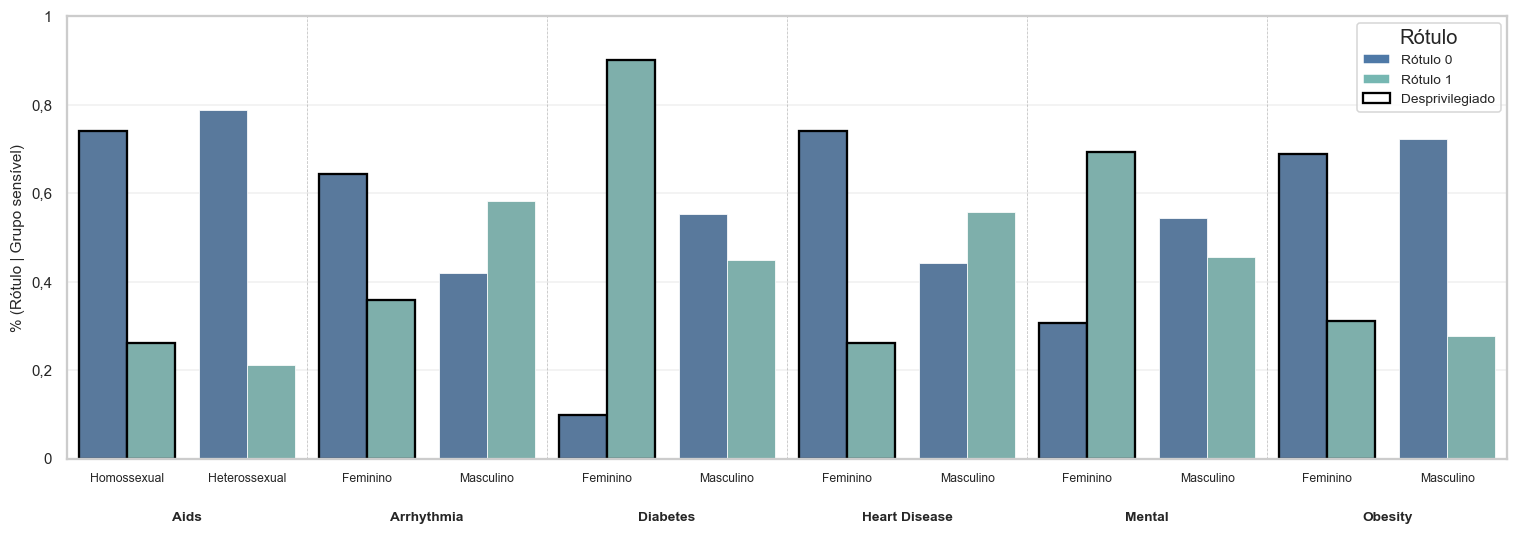

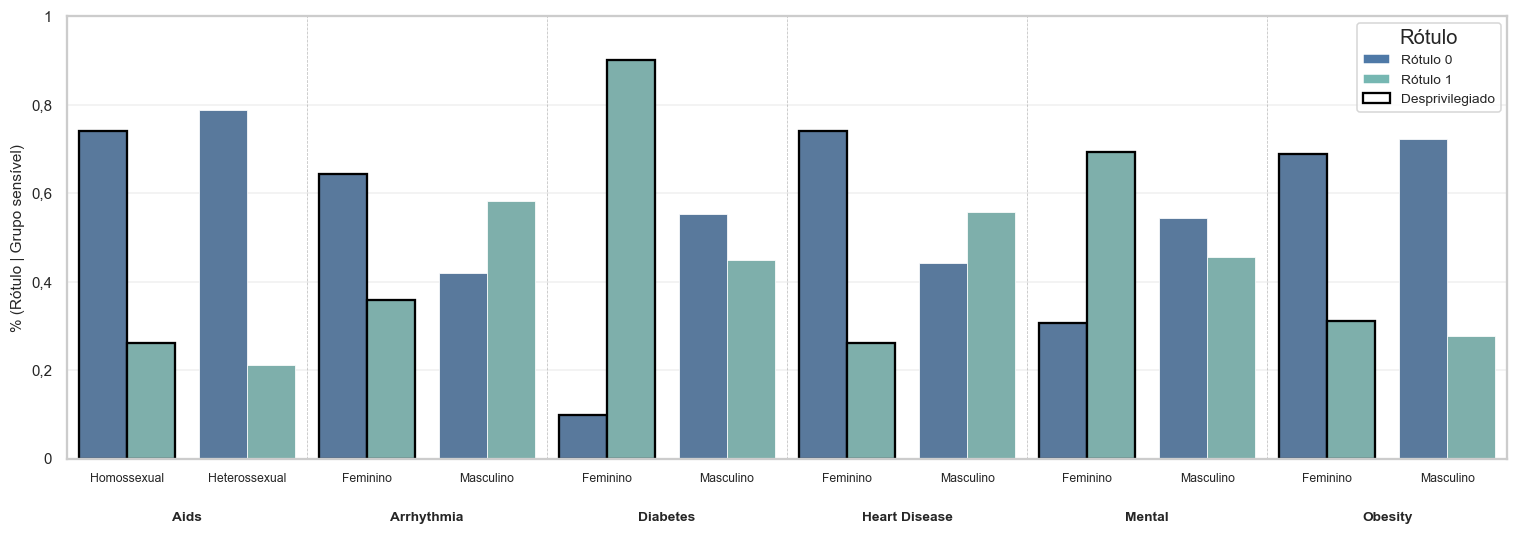

In [7]:
plot_target_by_sensitive_group(
    combined,
    save_path=FIGS / "dist_target_sens.pdf",
)

## Distribuições de features por dataset

Para cada dataset ativo, gera figuras de distribuição de cada feature:
- Categóricas: histograma agrupado por grupo sensível
- Numéricas: densidade por grupo sensível e por variável resposta

  HEART: 24 figuras geradas (0 cat, 12 num)
  AIDS: 42 figuras geradas (0 cat, 21 num)
  OBESITY: 38 figuras geradas (0 cat, 19 num)
  ARRHYTHMIA: 554 figuras geradas (0 cat, 277 num)


MemoryError: Unable to allocate 445. GiB for an array with shape (59701434013,) and data type float64

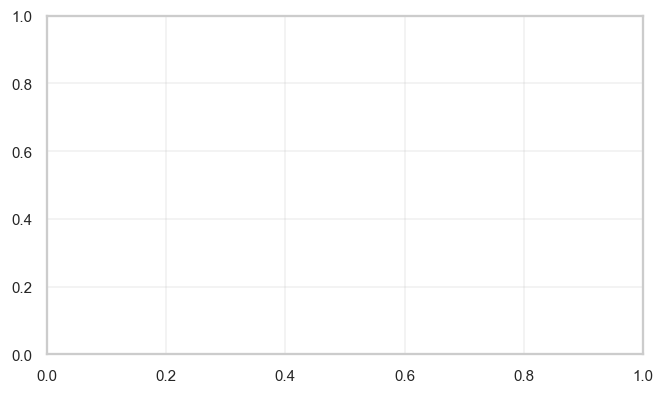

In [8]:
for ds_name, ds_cfg in DATASET_CONFIGS.items():
    if not ds_cfg.get("active", False):
        continue
    ds_figs = FIGS / ds_name.lower()
    plot_feature_distributions(ds_name, data_root=data_root, save_dir=ds_figs)